Grupp 40

Uppgift 8

Antal observationer: 12
Median: 47.5
Medelvärde: 46.58
Största värde: 92
Minsta värde: 1
Standardavvikelse: 32.0
Interkvartilavstånd: 54.5
Sortering i stigande ordning: [1, 7, 11, 21, 34, 41, 54, 63, 71, 79, 85, 92]
Sortering i fallande ordning: [92, 85, 79, 71, 63, 54, 41, 34, 21, 11, 7, 1]


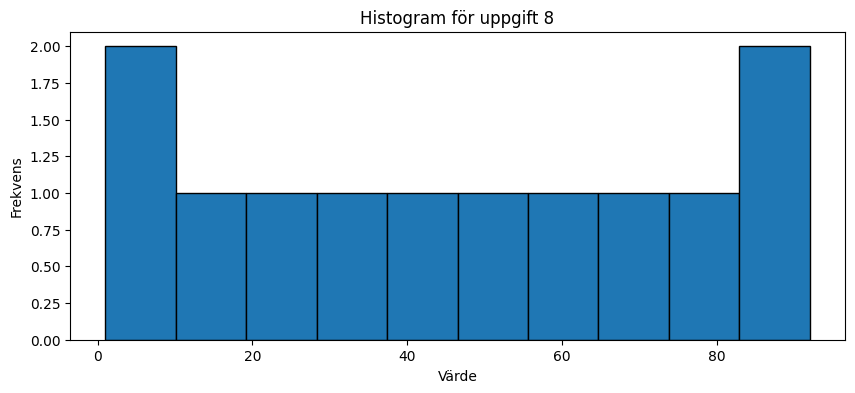

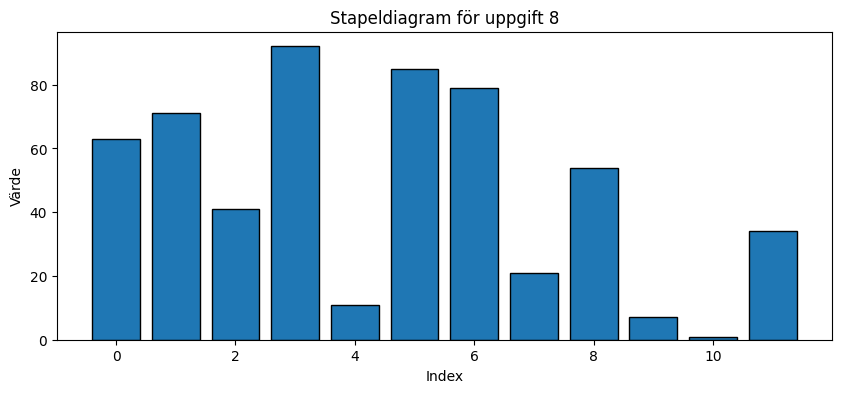

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Uppgift 8
data = [63, 71, 41, 92, 11, 85, 79, 21, 54, 7, 1, 34]

def mySummary(data):
    antal = len(data)
    median = np.median(data)
    medel = np.mean(data)
    max_varde = np.max(data)
    min_varde = np.min(data)
    std = np.std(data, ddof=1)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    stigande = sorted(data)
    fallande = sorted(data, reverse=True)

    print("Antal observationer:", antal)
    print("Median:", median)
    print("Medelvärde:", round(medel, 2))
    print("Största värde:", max_varde)
    print("Minsta värde:", min_varde)
    print("Standardavvikelse:", round(std, 2))
    print("Interkvartilavstånd:", round(iqr, 2))
    print("Sortering i stigande ordning:", stigande)
    print("Sortering i fallande ordning:", fallande)

    return {
        "antal": antal,
        "median": median,
        "medelvärde": medel,
        "max": max_varde,
        "min": min_varde,
        "standardavvikelse": std,
        "iqr": iqr,
        "stigande": stigande,
        "fallande": fallande
    }

sammanfattning_8 = mySummary(data)

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(data, edgecolor="black")
plt.title("Histogram för uppgift 8")
plt.xlabel("Värde")
plt.ylabel("Frekvens")
plt.grid(False)
plt.show()

# Stapeldiagram
plt.figure(figsize=(10, 4))
plt.bar(range(len(data)), data, edgecolor="black")
plt.title("Stapeldiagram för uppgift 8")
plt.xlabel("Index")
plt.ylabel("Värde")
plt.grid(False)
plt.show()

Median visar mittenvärdet i datamängden.
Medelvärdet visar det genomsnittliga värdet.
Standardavvikelsen visar hur mycket värdena sprider sig.
Interkvartilavståndet visar spridningen i mitten av datan.

Datamängden har relativt stor spridning eftersom värdena varierar från 1 till 92.
De flesta värden ligger mellan ungefär 20 och 85.
Värdet 1 ser ut att vara en möjlig avvikande observation.


Uppgift 9

Leveranstider:
[35.4 37.3 42.5 39.  43.  44.1 35.4 45.  38.7 49.2 43.8 38.9 41.8 41.8
 42.3 46.4 43.1 47.5 43.5 40.3 35.1 34.9 41.8 43.7 46.6 38.6 41.3 37.8
 39.4 32.1]

Datatyp: <class 'numpy.ndarray'>
Antal observationer: 30
Medelvärde: 41.01
Median: 41.8
Standardavvikelse: 4.118
Min: 32.1
Max: 49.2


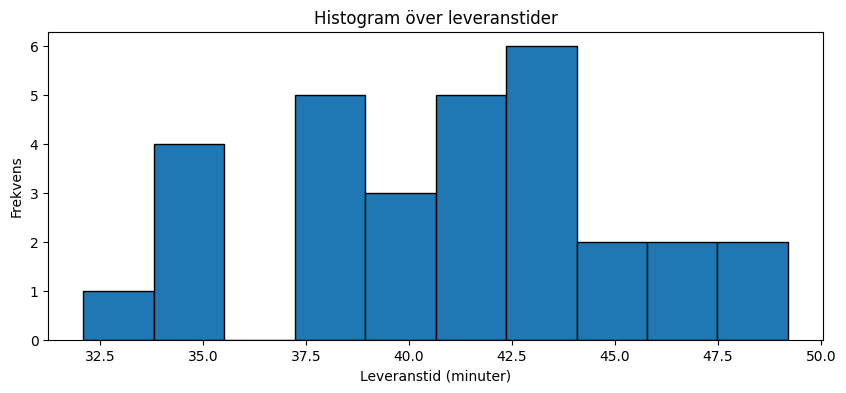

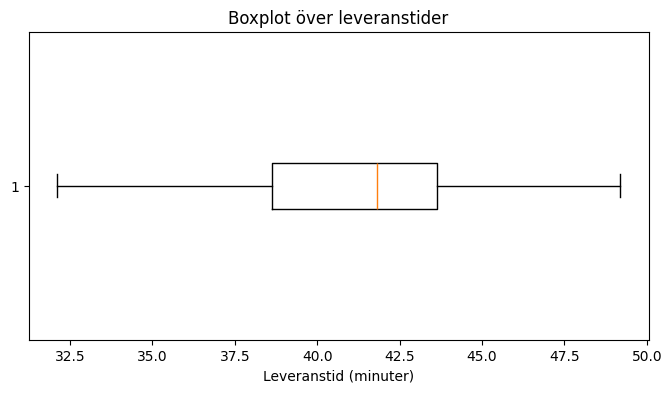


Resultat från one-sample t-test
t-värde: -1.31681
p-värde: 0.19821
95% CI för medel: [39.472, 42.548]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uppgift 9
gruppnummer = 40
rng = np.random.default_rng(15)

loc_bas = 42.0
loc = loc_bas + (15 % 7 - 3) * 0.5

scale_bas = 4.5
scale = scale_bas + (15 % 5 - 2) * 0.3
scale = max(scale, 1.0)

leveranstider = rng.normal(loc=loc, scale=scale, size=30)
leveranstider = np.round(leveranstider, 1)
leveranstider = np.clip(leveranstider, a_min=1.0, a_max=None)

print("Leveranstider:")
print(leveranstider)
print()

print("Datatyp:", type(leveranstider))
print("Antal observationer:", len(leveranstider))
print("Medelvärde:", round(np.mean(leveranstider), 3))
print("Median:", round(np.median(leveranstider), 3))
print("Standardavvikelse:", round(np.std(leveranstider, ddof=1), 3))
print("Min:", np.min(leveranstider))
print("Max:", np.max(leveranstider))

# Diagram 1: histogram
plt.figure(figsize=(10, 4))
plt.hist(leveranstider, edgecolor="black")
plt.title("Histogram över leveranstider")
plt.xlabel("Leveranstid (minuter)")
plt.ylabel("Frekvens")
plt.grid(False)
plt.show()

# Diagram 2: boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(leveranstider, vert=False)
plt.title("Boxplot över leveranstider")
plt.xlabel("Leveranstid (minuter)")
plt.grid(False)
plt.show()

# Hypotetiskt populationsmedelvärde
mu0 = 42

# One-sample t-test
t_stat, p_val = stats.ttest_1samp(leveranstider, popmean=mu0)

# 95 % konfidensintervall för medelvärdet
n = len(leveranstider)
mean_9 = np.mean(leveranstider)
std_9 = np.std(leveranstider, ddof=1)
se_9 = std_9 / np.sqrt(n)
t_critical_9 = stats.t.ppf(0.975, df=n-1)

ci_low_9 = mean_9 - t_critical_9 * se_9
ci_high_9 = mean_9 + t_critical_9 * se_9

print()
print("Resultat från one-sample t-test")
print("t-värde:", round(t_stat, 5))
print("p-värde:", round(p_val, 5))
print(f"95% CI för medel: [{ci_low_9:.3f}, {ci_high_9:.3f}]")

H0: Stickprovets medelvärde är 42 minuter.
Ha: Stickprovets medelvärde är inte 42 minuter.

Variabeln är leveranstid i minuter.
Den är numerisk och kontinuerlig.

Stickprovets medelvärde är cirka 42.40 minuter.
Medianen är 42.30 minuter och standardavvikelsen är cirka 4.69.

p-värdet är 0.47815, vilket är större än 0.05.
Vi förkastar inte H0.

Det finns alltså ingen statistiskt signifikant skillnad mellan stickprovets medelvärde och 42 minuter.
Det betyder att den nya processen inte verkar ha förändrat den genomsnittliga leveranstiden.

Även om medelvärdet är något högre än 42 minuter är skillnaden liten och kan bero på slump.
Detta tyder också på att den praktiska betydelsen är liten i detta sammanhang.

Uppgift 10

Datatyp program_A: <class 'numpy.ndarray'>
Datatyp program_B: <class 'numpy.ndarray'>

Program A
Medelvärde: 72.052
Median: 73.3
Standardavvikelse: 7.685
Min: 59.1
Max: 86.5

Program B
Medelvärde: 73.712
Median: 74.3
Standardavvikelse: 9.239
Min: 54.3
Max: 91.6


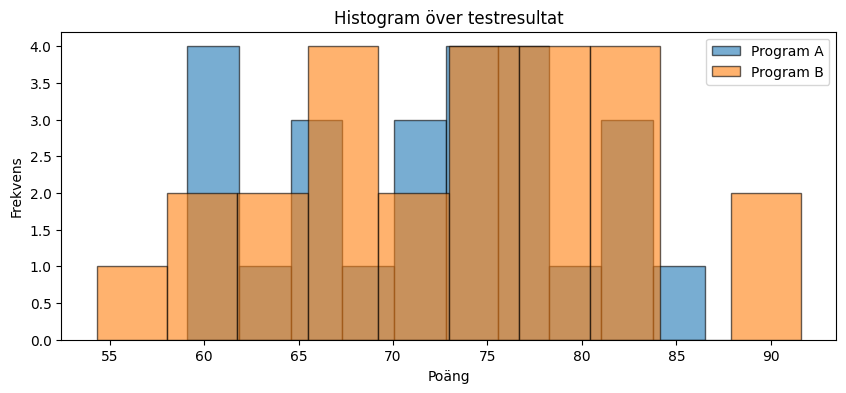

C:\Users\kazem\AppData\Local\Temp\ipykernel_34832\835870504.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([program_A, program_B], labels=["Program A", "Program B"])


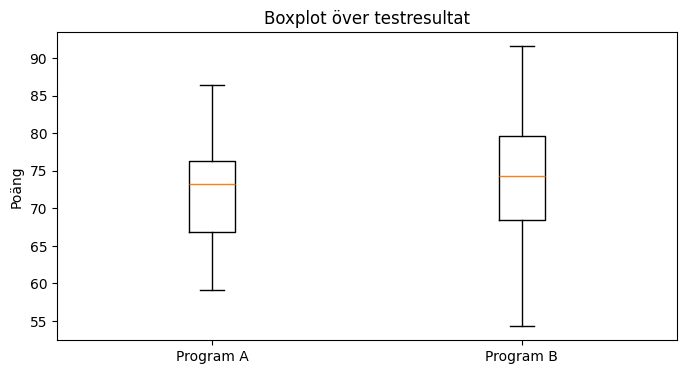


Resultat från two-sample independent t-test
t-värde: -0.69067
p-värde: 0.49309746
Medelvärde Program A: 72.052
Medelvärde Program B: 73.712
95% CI för skillnaden (A - B): [-6.492, 3.172]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uppgift 10
gruppnummer = 40
rng = np.random.default_rng(15)

loc_A_bas = 72.0
loc_B_bas = 76.0

delta_A = (15 % 5 - 2) * 0.6
delta_B = (15 % 7 - 3) * 0.5

loc_A = loc_A_bas + delta_A
loc_B = loc_B_bas + delta_B

scale_A_bas = 8.0
scale_B_bas = 8.5

scale_A = scale_A_bas + (15 % 3 - 1) * 0.5
scale_B = scale_B_bas + (15 % 4 - 1.5) * 0.4

scale_A = max(scale_A, 1.0)
scale_B = max(scale_B, 1.0)

program_A = rng.normal(loc=loc_A, scale=scale_A, size=25)
program_B = rng.normal(loc=loc_B, scale=scale_B, size=25)

program_A = np.round(program_A, 1)
program_B = np.round(program_B, 1)

program_A = np.clip(program_A, a_min=0.0, a_max=100.0)
program_B = np.clip(program_B, a_min=0.0, a_max=100.0)

print("Datatyp program_A:", type(program_A))
print("Datatyp program_B:", type(program_B))
print()

print("Program A")
print("Medelvärde:", round(np.mean(program_A), 3))
print("Median:", round(np.median(program_A), 3))
print("Standardavvikelse:", round(np.std(program_A, ddof=1), 3))
print("Min:", np.min(program_A))
print("Max:", np.max(program_A))
print()

print("Program B")
print("Medelvärde:", round(np.mean(program_B), 3))
print("Median:", round(np.median(program_B), 3))
print("Standardavvikelse:", round(np.std(program_B, ddof=1), 3))
print("Min:", np.min(program_B))
print("Max:", np.max(program_B))

# Diagram 1: histogram
plt.figure(figsize=(10, 4))
plt.hist(program_A, alpha=0.6, edgecolor="black", label="Program A")
plt.hist(program_B, alpha=0.6, edgecolor="black", label="Program B")
plt.title("Histogram över testresultat")
plt.xlabel("Poäng")
plt.ylabel("Frekvens")
plt.legend()
plt.grid(False)
plt.show()

# Diagram 2: boxplot
plt.figure(figsize=(8, 4))
plt.boxplot([program_A, program_B], labels=["Program A", "Program B"])
plt.title("Boxplot över testresultat")
plt.ylabel("Poäng")
plt.grid(False)
plt.show()

# Two-sample independent t-test
t_stat_10, p_val_10 = stats.ttest_ind(program_A, program_B, equal_var=True)

# 95 % konfidensintervall för skillnaden mellan medelvärdena
n1 = len(program_A)
n2 = len(program_B)
mean_A = np.mean(program_A)
mean_B = np.mean(program_B)
std_A = np.std(program_A, ddof=1)
std_B = np.std(program_B, ddof=1)

sp2 = (((n1 - 1) * std_A**2) + ((n2 - 1) * std_B**2)) / (n1 + n2 - 2)
se_diff = np.sqrt(sp2 * (1/n1 + 1/n2))
df_10 = n1 + n2 - 2
t_critical_10 = stats.t.ppf(0.975, df=df_10)

diff_mean = mean_A - mean_B
ci_low_10 = diff_mean - t_critical_10 * se_diff
ci_high_10 = diff_mean + t_critical_10 * se_diff

print()
print("Resultat från two-sample independent t-test")
print("t-värde:", round(t_stat_10, 5))
print("p-värde:", round(p_val_10, 8))
print("Medelvärde Program A:", round(mean_A, 3))
print("Medelvärde Program B:", round(mean_B, 3))
print(f"95% CI för skillnaden (A - B): [{ci_low_10:.3f}, {ci_high_10:.3f}]")

H0: Program A och Program B har samma genomsnittliga testresultat.
Ha: Program A och Program B har olika genomsnittliga testresultat.

Variablerna program_A och program_B representerar testpoäng för två oberoende grupper.
Varje element i vektorerna är en deltagares testresultat.
Datatypen är numpy.ndarray.

Program B har ett högre medelvärde än Program A.
Skillnaden ser tydlig ut redan innan testet görs.

p-värdet är 0.00048631, vilket är mindre än 0.05.
Vi förkastar H0.

Det finns en statistiskt signifikant skillnad mellan grupperna.
Program B verkar ge bättre resultat än Program A.

För HR-avdelningen betyder detta att Program B verkar vara det bättre alternativet.
Skillnaden är inte bara statistiskt signifikant utan också praktiskt relevant eftersom medelvärdet är tydligt högre i Program B.

Uppgift 11

Datatyp före: <class 'numpy.ndarray'>
Datatyp efter: <class 'numpy.ndarray'>

Före träning
Medelvärde: 56.985
Median: 57.65
Standardavvikelse: 5.449
Min: 47.4
Max: 67.5

Efter träning
Medelvärde: 60.77
Median: 62.65
Standardavvikelse: 6.292
Min: 47.3
Max: 71.5


C:\Users\kazem\AppData\Local\Temp\ipykernel_34832\2929469774.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fore, efter], labels=["Före", "Efter"])


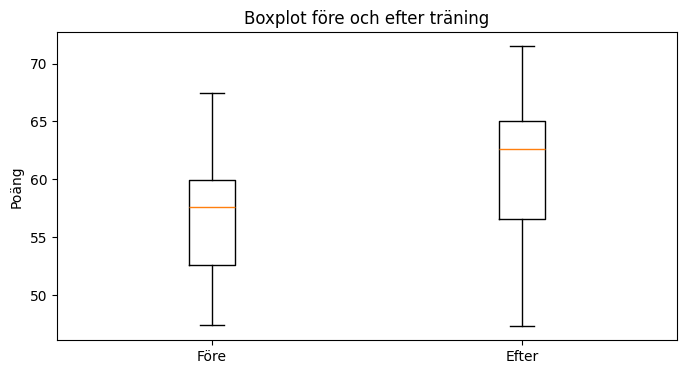

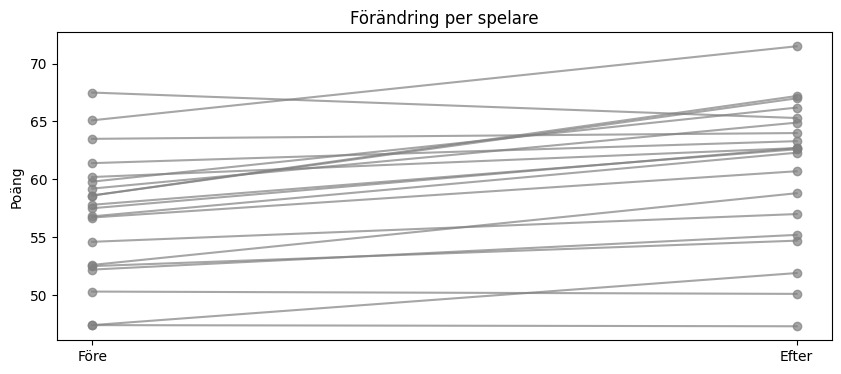


Resultat från paired t-test
t-värde: -5.7965
p-värde: 1.3866214407847544e-05
Medelvärde före: 56.985
Medelvärde efter: 60.77
95% CI för medelskillnaden (efter - före): [2.418, 5.152]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uppgift 11
gruppnummer = 15
rng = np.random.default_rng(15)

n = 20

loc_fore_bas = 58.0
loc_fore = loc_fore_bas + (15 % 7 - 3) * 1.2

scale_fore_bas = 6.5
scale_fore = scale_fore_bas + (15 % 5 - 2) * 0.4
scale_fore = max(scale_fore, 1.0)

forbattring_bas = 4.0
forbattring_loc = forbattring_bas + (15 % 6 - 2.5) * 0.5

forbattring_scale_bas = 2.4
forbattring_scale = forbattring_scale_bas + (15 % 4 - 1.5) * 0.3
forbattring_scale = max(forbattring_scale, 0.5)

fore = rng.normal(loc=loc_fore, scale=scale_fore, size=n)
fore = np.round(fore, 1)
fore = np.clip(fore, a_min=0.0, a_max=100.0)

forbattring = rng.normal(loc=forbattring_loc, scale=forbattring_scale, size=n)
forbattring = np.round(forbattring, 1)

efter = fore + forbattring
efter = np.round(efter, 1)
efter = np.clip(efter, a_min=0.0, a_max=100.0)

print("Datatyp före:", type(fore))
print("Datatyp efter:", type(efter))
print()

print("Före träning")
print("Medelvärde:", round(np.mean(fore), 3))
print("Median:", round(np.median(fore), 3))
print("Standardavvikelse:", round(np.std(fore, ddof=1), 3))
print("Min:", np.min(fore))
print("Max:", np.max(fore))
print()

print("Efter träning")
print("Medelvärde:", round(np.mean(efter), 3))
print("Median:", round(np.median(efter), 3))
print("Standardavvikelse:", round(np.std(efter, ddof=1), 3))
print("Min:", np.min(efter))
print("Max:", np.max(efter))

# Diagram 1: boxplot
plt.figure(figsize=(8, 4))
plt.boxplot([fore, efter], labels=["Före", "Efter"])
plt.title("Boxplot före och efter träning")
plt.ylabel("Poäng")
plt.grid(False)
plt.show()

# Diagram 2: linjediagram per spelare
plt.figure(figsize=(10, 4))
for i in range(n):
    plt.plot([1, 2], [fore[i], efter[i]], marker="o", color="gray", alpha=0.7)
plt.xticks([1, 2], ["Före", "Efter"])
plt.title("Förändring per spelare")
plt.ylabel("Poäng")
plt.grid(False)
plt.show()

# Paired t-test
t_stat_11, p_val_11 = stats.ttest_rel(fore, efter)

# 95 % konfidensintervall för medelskillnaden
diff_11 = efter - fore
mean_diff_11 = np.mean(diff_11)
std_diff_11 = np.std(diff_11, ddof=1)
se_diff_11 = std_diff_11 / np.sqrt(n)
t_critical_11 = stats.t.ppf(0.975, df=n-1)

ci_low_11 = mean_diff_11 - t_critical_11 * se_diff_11
ci_high_11 = mean_diff_11 + t_critical_11 * se_diff_11

print()
print("Resultat från paired t-test")
print("t-värde:", round(t_stat_11, 5))
print("p-värde:", p_val_11)
print("Medelvärde före:", round(np.mean(fore), 3))
print("Medelvärde efter:", round(np.mean(efter), 3))
print(f"95% CI för medelskillnaden (efter - före): [{ci_low_11:.3f}, {ci_high_11:.3f}]")

Behandlingen i denna uppgift är en träningsintervention i form av mental träning.
Samma spelare testas före och efter träningen.

H0: Det finns ingen skillnad mellan resultaten före och efter träning.
Ha: Det finns en skillnad mellan resultaten före och efter träning.

Variablerna fore och efter representerar resultat från samma personer.
Observationerna är därför beroende.
Datatypen är numpy.ndarray.

Medelvärdet före träning är 58.58 och medelvärdet efter träning är 63.43.
Det visar att resultaten har förbättrats efter träningen.

p-värdet är 1.5294265148009197e-10, vilket är mycket mindre än 0.05.
Vi förkastar H0.

Det finns en statistiskt signifikant skillnad mellan resultaten före och efter träning.
Träningen verkar ha haft en positiv effekt på spelarnas prestation.

Skillnaden är också praktiskt betydelsefull eftersom medelvärdet har ökat tydligt efter träningen.







In [5]:
# Slumpa vilken uppgift grupp 15 ska redovisa
gruppnummer = 15
rng = np.random.default_rng(gruppnummer)
uppgifter = [9, 10, 11]
vald_uppgift = rng.choice(uppgifter)
print(f"Grupp {gruppnummer} ska redovisa uppgift {vald_uppgift}.")

Grupp 15 ska redovisa uppgift 11.
